# Lab Day 19 — Building a GraphRAG System

**Goal:** build a full **GraphRAG** pipeline from a raw text corpus and compare it
against a plain **Flat RAG** baseline.

This notebook walks through the lab end-to-end:

1. **Entity & Relation Extraction** — turn unstructured text into `(subject, relation, object)` triples with an LLM or **[LangExtract](https://github.com/google/langextract)** (few-shot, source-grounded extraction).
2. **Graph Construction** — deduplicate entities and build a knowledge graph (**NetworkX**, optionally mirrored to **Neo4j**).
3. **Indexing** — embed chunks into a vector index for retrieval.
4. **GraphRAG Querying** — link a question to graph entities, traverse a **multi-hop** subgraph, and answer from graph facts + supporting text.
5. **Flat RAG vs GraphRAG** — run the same questions through both and compare.

> **Runs offline by default** using **Ollama** + **NetworkX** (no API key, no database).
> Switch to **OpenAI** and/or **Neo4j** by changing the single `CONFIG` cell below.

## Part 0 — Setup & Configuration

**Before running:**

- *Offline path (default):* install [Ollama](https://ollama.com), then in a terminal:
  ```
  ollama serve
  ollama pull llama3.1
  ollama pull nomic-embed-text
  ```
- *OpenAI path:* set `LLM_PROVIDER = "openai"` in CONFIG and export `OPENAI_API_KEY`.
- *LangExtract path (recommended):* set `EXTRACTION_BACKEND = "langextract"` in CONFIG — works with Ollama (offline) or OpenAI; uses few-shot examples for more consistent triples.
- *Neo4j (optional):* set `GRAPH_BACKEND = "neo4j"` and fill the Neo4j credentials.

In [1]:
%pip install -q networkx numpy pandas matplotlib requests tqdm openai neo4j langextract


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, json, glob, difflib, collections
import numpy as np
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

Matplotlib is building the font cache; this may take a moment.


/Users/hanhvs/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ====================== CONFIG ======================
LLM_PROVIDER       = "openai"        # "ollama" (offline) | "openai"
GRAPH_BACKEND      = "networkx"      # "networkx" | "neo4j"
EXTRACTION_BACKEND = "prompt"        # "prompt" (raw JSON prompt, no extra deps) | "langextract"

# --- OpenAI (used when LLM_PROVIDER == "openai") ---
os.environ.setdefault("OPENAI_API_KEY", "")      # or export it in your shell
OPENAI_MODEL       = "gpt-4o-mini"
OPENAI_EMBED_MODEL = "text-embedding-3-small"

# --- Ollama (used when LLM_PROVIDER == "ollama") ---
OLLAMA_HOST        = "http://localhost:11434"
OLLAMA_MODEL       = "llama3.1"
OLLAMA_EMBED_MODEL = "nomic-embed-text"

# --- Neo4j (used when GRAPH_BACKEND == "neo4j") ---
NEO4J_URL      = "bolt://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = ""

# --- Data / runtime ---
DATASET_DIR   = "dataset"   # folder of *.txt documents
MAX_DOCS      = 30          # cap for speed; raise toward the full corpus (~70)
CHUNK_SIZE    = 1200        # characters per chunk
CHUNK_OVERLAP = 150

print(f"LLM_PROVIDER={LLM_PROVIDER} | EXTRACTION_BACKEND={EXTRACTION_BACKEND} | GRAPH_BACKEND={GRAPH_BACKEND} | MAX_DOCS={MAX_DOCS}")

LLM_PROVIDER=openai | EXTRACTION_BACKEND=prompt | GRAPH_BACKEND=networkx | MAX_DOCS=30


In [4]:
# ---- Provider-agnostic LLM + embedding wrappers (+ usage tracking) ----
import time
# ponytail: int += under the GIL is good enough for a cost estimate across threads
USAGE = {"llm_calls": 0, "prompt_tokens": 0, "completion_tokens": 0,
         "embed_calls": 0, "embed_tokens": 0, "llm_seconds": 0.0, "embed_seconds": 0.0}

def llm_complete(prompt, system=None, temperature=0.0, max_tokens=1200):
    """Send a prompt to the configured provider and return the text response."""
    t0 = time.time()
    if LLM_PROVIDER == "openai":
        from openai import OpenAI
        client = OpenAI()
        messages = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})
        resp = client.chat.completions.create(
            model=OPENAI_MODEL, messages=messages,
            temperature=temperature, max_tokens=max_tokens)
        u = resp.usage
        USAGE["llm_calls"] += 1
        USAGE["prompt_tokens"] += u.prompt_tokens
        USAGE["completion_tokens"] += u.completion_tokens
        USAGE["llm_seconds"] += time.time() - t0
        return resp.choices[0].message.content
    elif LLM_PROVIDER == "ollama":
        payload = {"model": OLLAMA_MODEL, "prompt": prompt, "stream": False,
                   "options": {"temperature": temperature, "num_predict": max_tokens}}
        if system:
            payload["system"] = system
        r = requests.post(OLLAMA_HOST + "/api/generate", json=payload, timeout=600)
        r.raise_for_status()
        USAGE["llm_calls"] += 1
        USAGE["llm_seconds"] += time.time() - t0
        return r.json()["response"]
    raise ValueError("Unknown LLM_PROVIDER: " + LLM_PROVIDER)

def embed(texts):
    """Return a list of 1-D numpy vectors, one per input string."""
    if isinstance(texts, str):
        texts = [texts]
    t0 = time.time()
    if LLM_PROVIDER == "openai":
        from openai import OpenAI
        client = OpenAI()
        resp = client.embeddings.create(model=OPENAI_EMBED_MODEL, input=texts)
        USAGE["embed_calls"] += 1
        USAGE["embed_tokens"] += resp.usage.total_tokens
        USAGE["embed_seconds"] += time.time() - t0
        return [np.array(d.embedding, dtype=float) for d in resp.data]
    out = []
    for t in texts:
        r = requests.post(OLLAMA_HOST + "/api/embeddings",
                          json={"model": OLLAMA_EMBED_MODEL, "prompt": t}, timeout=600)
        r.raise_for_status()
        out.append(np.array(r.json()["embedding"], dtype=float))
    USAGE["embed_seconds"] += time.time() - t0
    return out

In [5]:
# Smoke test — verifies the chosen provider responds (safe to re-run).
try:
    print("LLM says:", llm_complete("Reply with exactly: OK", max_tokens=10).strip()[:50])
    print("Embedding dim:", len(embed("hello world")[0]))
except Exception as e:
    print("Provider not reachable yet:", e)
    print("Ollama:  run `ollama serve` and pull `llama3.1` + `nomic-embed-text`.")
    print("OpenAI:  set LLM_PROVIDER='openai' and export OPENAI_API_KEY.")

LLM says: OK


Embedding dim: 1536


## Part 1 — Concepts (the lab's research questions)

**1. Entity Extraction — how does the LLM tell an *entity* from an *attribute*?**
We extract structured triples `(subject, relation, object)` with entity *types*.
By default we use **[LangExtract](https://github.com/google/langextract)** — few-shot examples
teach the schema, and each extraction can be traced back to its source span. The `prompt`
backend is a simpler single-shot JSON alternative. Entities become *nodes*; relationships become *edges*.

**2. Graph Construction — why does deduplication matter?**
The same real-world entity appears under many surface forms ("Tesla", "Tesla Inc.", "tesla").
If we don't merge them, the graph fragments: facts about one entity scatter across several nodes,
breaking traversal. We normalize names and fuzzy-merge near-duplicates into a single canonical node.

**3. Query Answering — graph traversal vs. plain vector search?**
*Flat RAG* embeds the query and returns the top-k most *similar* chunks — great for "what does the text say
about X", but blind to relationships that aren't co-located in one passage.
*GraphRAG* links the query to entities and **traverses** the graph (multi-hop) to assemble connected facts —
so it can answer "how is A connected to C *through* B" even when no single chunk states it.

## Part 2 — Load & Chunk the Corpus

We read the `*.txt` files from `DATASET_DIR` and split each into overlapping character chunks.

In [6]:
def load_documents(directory, max_docs=None):
    paths = sorted(glob.glob(os.path.join(directory, "*.txt")))
    if max_docs:
        paths = paths[:max_docs]
    docs = []
    for p in paths:
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            docs.append({"doc_id": os.path.basename(p), "text": f.read()})
    return docs

def chunk_text(text, size, overlap):
    text = text.strip()
    chunks, start = [], 0
    while start < len(text):
        end = start + size
        chunks.append(text[start:end])
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks

documents = load_documents(DATASET_DIR, MAX_DOCS)
chunks = []
for d in documents:
    for j, ctext in enumerate(chunk_text(d["text"], CHUNK_SIZE, CHUNK_OVERLAP)):
        chunks.append({"chunk_id": f"{d['doc_id']}::ch{j}",
                       "doc_id": d["doc_id"], "text": ctext})

print(f"Loaded {len(documents)} docs -> {len(chunks)} chunks")
print("\nExample chunk:\n", chunks[0]["text"][:300])

Loaded 30 docs -> 412 chunks

Example chunk:
 Query: US electric vehicle sector sentiment analysis
Title: Evaluating electric vehicle market growth across U.S. cities ...
Link: https://theicct.org/publication/evaluating-electric-vehicle-market-growth-across-u-s-cities/
Snippet: Sep 14, 2021 ... This study, an update of our previous analysis of 


## Part 3 — Entity & Relation Extraction

Two backends (set `EXTRACTION_BACKEND` in CONFIG):

| Backend | How it works | Best for |
|---------|--------------|----------|
| **`langextract`** (default) | Google's [LangExtract](https://github.com/google/langextract) library — few-shot examples, schema-guided output, source grounding | More consistent triples; same Ollama/OpenAI provider as the rest of the lab |
| **`prompt`** | Single-shot JSON prompt to the LLM | Minimal dependencies; quick baseline |

Both produce the same `(subject, relation, object)` triple list consumed by graph construction below.

In [7]:
import textwrap
try:
    import langextract as lx
    HAVE_LANGEXTRACT = True
except Exception:
    lx, HAVE_LANGEXTRACT = None, False

def parse_json_triples(raw):
    """Best-effort parse of an LLM response into a list of triple dicts."""
    if not raw:
        return []
    text = raw.strip()
    text = re.sub(r"^```[a-zA-Z]*", "", text).strip().strip("`").strip()
    try:
        data = json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if not m:
            return []
        try:
            data = json.loads(m.group(0))
        except Exception:
            return []
    return data.get("triples", []) if isinstance(data, dict) else []

EXTRACT_SYSTEM = "You are an information-extraction engine that builds knowledge graphs from text."

def extract_triples_prompt(text):
    """Single-shot JSON prompt extraction (original lab approach)."""
    prompt = (
        "Extract the key ENTITIES and RELATIONSHIPS from the text below.\n"
        "Return ONLY valid JSON in this exact shape (no prose, no markdown):\n"
        '{"triples": [{"subject": "", "subject_type": "", "relation": "", "object": "", "object_type": ""}]}\n\n'
        "Guidelines:\n"
        "- subject/object must be specific named entities (company, sector, technology, product, place, person, metric).\n"
        "- relation is a short snake_case verb phrase: operates_in, invests_in, competes_with, located_in, produces, reported.\n"
        "- Use canonical, concise entity names. Skip vague pronouns.\n"
        "- Return at most 15 of the most important triples.\n\n"
        "Text:\n<<<\n" + text[:3500] + "\n>>>"
    )
    raw = llm_complete(prompt, system=EXTRACT_SYSTEM, max_tokens=1200)
    return parse_json_triples(raw)

# ---- LangExtract: few-shot, schema-guided extraction ----
LX_PROMPT = textwrap.dedent("""\
    Extract named entities and relationships from market / EV-sector text for a knowledge graph.
    Use exact text spans from the source for extraction_text (no paraphrasing).
    List extractions in order of appearance.
    For relationships, set attributes: subject, subject_type, relation (snake_case),
    object, object_type. Relation examples: operates_in, invests_in, competes_with,
    located_in, produces, reported, promotes, correlates_with.
    Return at most 15 of the most important extractions per chunk.""")

LX_EXAMPLES = [] if not HAVE_LANGEXTRACT else [
    lx.data.ExampleData(
        text=(
            "States with zero-emission vehicle (ZEV) regulations had a combined new electric "
            "vehicle share of 5%. Metropolitan areas with the greatest electric vehicle uptake "
            "had substantial consumer incentives ranging from $1,500 to more than $5,500."
        ),
        extractions=[
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="zero-emission vehicle (ZEV) regulations",
                attributes={"entity_type": "policy"},
            ),
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="electric vehicle share",
                attributes={"entity_type": "metric"},
            ),
            lx.data.Extraction(
                extraction_class="relationship",
                extraction_text=(
                    "States with zero-emission vehicle (ZEV) regulations had a combined new "
                    "electric vehicle share of 5%"
                ),
                attributes={
                    "subject": "zero-emission vehicle regulations",
                    "subject_type": "policy",
                    "relation": "correlates_with",
                    "object": "electric vehicle market share",
                    "object_type": "metric",
                },
            ),
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="consumer incentives",
                attributes={"entity_type": "policy"},
            ),
            lx.data.Extraction(
                extraction_class="relationship",
                extraction_text=(
                    "Metropolitan areas with the greatest electric vehicle uptake had "
                    "substantial consumer incentives"
                ),
                attributes={
                    "subject": "consumer incentives",
                    "subject_type": "policy",
                    "relation": "promotes",
                    "object": "electric vehicle uptake",
                    "object_type": "metric",
                },
            ),
        ],
    )
]

def _langextract_model_kwargs():
    if LLM_PROVIDER == "ollama":
        return {"model_id": OLLAMA_MODEL, "model_url": OLLAMA_HOST}
    if LLM_PROVIDER == "openai":
        return {"model_id": OPENAI_MODEL}
    raise ValueError("Unknown LLM_PROVIDER: " + LLM_PROVIDER)

def lx_extractions_to_triples(result):
    """Convert LangExtract relationship extractions into lab triple dicts."""
    triples = []
    for ext in (result.extractions or []):
        if ext.extraction_class != "relationship":
            continue
        attrs = ext.attributes or {}
        s = attrs.get("subject") or attrs.get("head")
        o = attrs.get("object") or attrs.get("tail")
        r = attrs.get("relation") or attrs.get("predicate")
        if not (s and o and r):
            continue
        triples.append({
            "subject": str(s).strip(),
            "subject_type": str(attrs.get("subject_type", "")).strip(),
            "relation": str(r).strip(),
            "object": str(o).strip(),
            "object_type": str(attrs.get("object_type", "")).strip(),
        })
    return triples

def extract_triples_langextract(text):
    if not HAVE_LANGEXTRACT:
        raise RuntimeError("langextract not installed; set EXTRACTION_BACKEND='prompt'")
    result = lx.extract(
        text_or_documents=text[:3500],
        prompt_description=LX_PROMPT,
        examples=LX_EXAMPLES,
        max_char_buffer=min(CHUNK_SIZE, 1200),
        **_langextract_model_kwargs(),
    )
    return lx_extractions_to_triples(result)

def extract_triples(text):
    """Dispatch to the configured extraction backend."""
    if EXTRACTION_BACKEND == "langextract":
        return extract_triples_langextract(text)
    if EXTRACTION_BACKEND == "prompt":
        return extract_triples_prompt(text)
    raise ValueError("Unknown EXTRACTION_BACKEND: " + EXTRACTION_BACKEND)

# Demo on a single chunk
extract_triples(chunks[0]["text"])[:5]

[{'subject': 'United States',
  'subject_type': 'place',
  'relation': 'operates_in',
  'object': 'electric vehicle sector',
  'object_type': 'sector'},
 {'subject': 'electric vehicle market',
  'subject_type': 'technology',
  'relation': 'produces',
  'object': '315,000 vehicles',
  'object_type': 'metric'},
 {'subject': '2020',
  'subject_type': 'metric',
  'relation': 'reported',
  'object': '2.4%',
  'object_type': 'metric'},
 {'subject': '2019',
  'subject_type': 'metric',
  'relation': 'reported',
  'object': '2%',
  'object_type': 'metric'},
 {'subject': 'state actions',
  'subject_type': 'policy',
  'relation': 'promotes',
  'object': 'electric vehicles',
  'object_type': 'technology'}]

In [8]:
# Run extraction across all chunks (parallel — this is the slow/costly step).
from concurrent.futures import ThreadPoolExecutor
import time

def _safe_extract(ch):
    try:
        return ch, extract_triples(ch["text"])
    except Exception:
        return ch, []

all_triples = []   # each: chunk_id, doc_id, subject, subject_type, relation, object, object_type
t0 = time.time()
with ThreadPoolExecutor(max_workers=12) as ex:
    for ch, triples in tqdm(ex.map(_safe_extract, chunks), total=len(chunks),
                            desc=f"Extracting ({EXTRACTION_BACKEND})"):
        for t in triples:
            if not (t.get("subject") and t.get("object") and t.get("relation")):
                continue
            all_triples.append({
                "chunk_id": ch["chunk_id"], "doc_id": ch["doc_id"],
                "subject": str(t["subject"]).strip(),
                "subject_type": str(t.get("subject_type", "")).strip(),
                "relation": str(t["relation"]).strip(),
                "object": str(t["object"]).strip(),
                "object_type": str(t.get("object_type", "")).strip(),
            })
EXTRACT_SECONDS = time.time() - t0
print(f"Extracted {len(all_triples)} raw triples from {len(chunks)} chunks in {EXTRACT_SECONDS:.1f}s")

Extracted 5646 raw triples from 412 chunks in 229.4s


In [9]:
pd.DataFrame(all_triples).head(15)

,chunk_id,doc_id,subject,subject_type,relation,object,object_type
0,doc_1.txt::ch0,doc_1.txt,United States,place,operates_in,electric vehicle sector,sector
1,doc_1.txt::ch0,doc_1.txt,electric vehicle market,product,reported,growth,metric
2,doc_1.txt::ch0,doc_1.txt,electric vehicle sales,metric,increased_from,2%,metric
3,doc_1.txt::ch0,doc_1.txt,electric vehicle sales,metric,increased_to,2.4%,metric
4,doc_1.txt::ch0,doc_1.txt,electric vehicle market,product,produces,"315,000 vehicles",metric
5,doc_1.txt::ch0,doc_1.txt,states,place,promotes,electric vehicles,product
6,doc_1.txt::ch0,doc_1.txt,regulations,technology,require,greater electric vehicle model availability,technology
7,doc_1.txt::ch0,doc_1.txt,policy supports,technology,strengthens,electric vehicle market success,metric
8,doc_1.txt::ch0,doc_1.txt,utility companies,company,promotes,electric vehicles,product
9,doc_1.txt::ch0,doc_1.txt,cities,place,supports,electric vehicle market,product


### (Optional) LangExtract source-grounding visualization

When `EXTRACTION_BACKEND == "langextract"`, re-run extraction on one chunk and generate
an interactive HTML map of extractions back to source text spans.

In [10]:
if EXTRACTION_BACKEND == "langextract":
    demo_text = chunks[0]["text"][:2500]
    lx_result = lx.extract(
        text_or_documents=demo_text,
        prompt_description=LX_PROMPT,
        examples=LX_EXAMPLES,
        max_char_buffer=min(CHUNK_SIZE, 1200),
        **_langextract_model_kwargs(),
    )
    lx.io.save_annotated_documents([lx_result], output_name="lx_demo.jsonl", output_dir=".")
    html = lx.visualize("lx_demo.jsonl")
    html_path = "lx_extraction_viz.html"
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html.data if hasattr(html, "data") else html)
    print(f"Saved interactive visualization -> {html_path}")
    print(f"Grounded extractions: {sum(1 for e in lx_result.extractions if e.char_interval)} / {len(lx_result.extractions)}")
else:
    print("Set EXTRACTION_BACKEND='langextract' to generate the HTML visualization.")

Set EXTRACTION_BACKEND='langextract' to generate the HTML visualization.


## Part 4 — Graph Construction (with Deduplication)

We normalize entity names and fuzzy-merge near-duplicates into canonical nodes,
then build a directed multigraph in **NetworkX**. Each edge remembers which chunk it came from
(provenance), so GraphRAG can pull the supporting text later.

In [11]:
def normalize(name):
    n = re.sub(r"\s+", " ", str(name)).strip()
    return n.strip(' .,:;"\'')

# Build a canonical alias map by fuzzy-merging surface forms.
raw_entities = sorted({normalize(t[k]) for t in all_triples for k in ("subject", "object")} - {""})

canonical, canon_list = {}, []
for e in raw_entities:
    match = difflib.get_close_matches(e.lower(), [c.lower() for c in canon_list], n=1, cutoff=0.92)
    if match:
        canonical[e] = next(c for c in canon_list if c.lower() == match[0])
    else:
        canon_list.append(e)
        canonical[e] = e

def canon(name):
    return canonical.get(normalize(name), normalize(name))

print(f"{len(raw_entities)} surface entities -> {len(canon_list)} canonical entities after dedup")

5043 surface entities -> 4702 canonical entities after dedup


In [12]:
G = nx.MultiDiGraph()
entity_chunks = {}   # canonical entity -> set of chunk_ids (provenance)
entity_type = {}

for t in all_triples:
    s, o = canon(t["subject"]), canon(t["object"])
    if not s or not o:
        continue
    if t["subject_type"]:
        entity_type.setdefault(s, t["subject_type"])
    if t["object_type"]:
        entity_type.setdefault(o, t["object_type"])
    G.add_node(s, type=entity_type.get(s, ""))
    G.add_node(o, type=entity_type.get(o, ""))
    G.add_edge(s, o, relation=t["relation"], chunk_id=t["chunk_id"], doc_id=t["doc_id"])
    entity_chunks.setdefault(s, set()).add(t["chunk_id"])
    entity_chunks.setdefault(o, set()).add(t["chunk_id"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 4702 nodes, 5646 edges


In [13]:
print("Top entities by degree:")
for n, d in sorted(G.degree, key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {d:3d}  {n}  ({G.nodes[n].get('type','')})")

Top entities by degree:
  540  Polestar  (company)
  171  REE  (company)
  158  Electric Vehicle  (product)
  141  NVIDIA  (company)
  125  VinFast  (company)
  125  Company  (company)
  110  China  (country)
   92  Tesla  (company)
   86  Polestar Automotive Holding UK PLC  (company)
   77  ZEEKR  (company)
   70  ZEEKR INC  (company)
   66  EVs  (technology)
   62  @CoxAutomotive  (company)
   62  Joint Office  (organization)
   61  United States  (place)


saved knowledge_graph.png


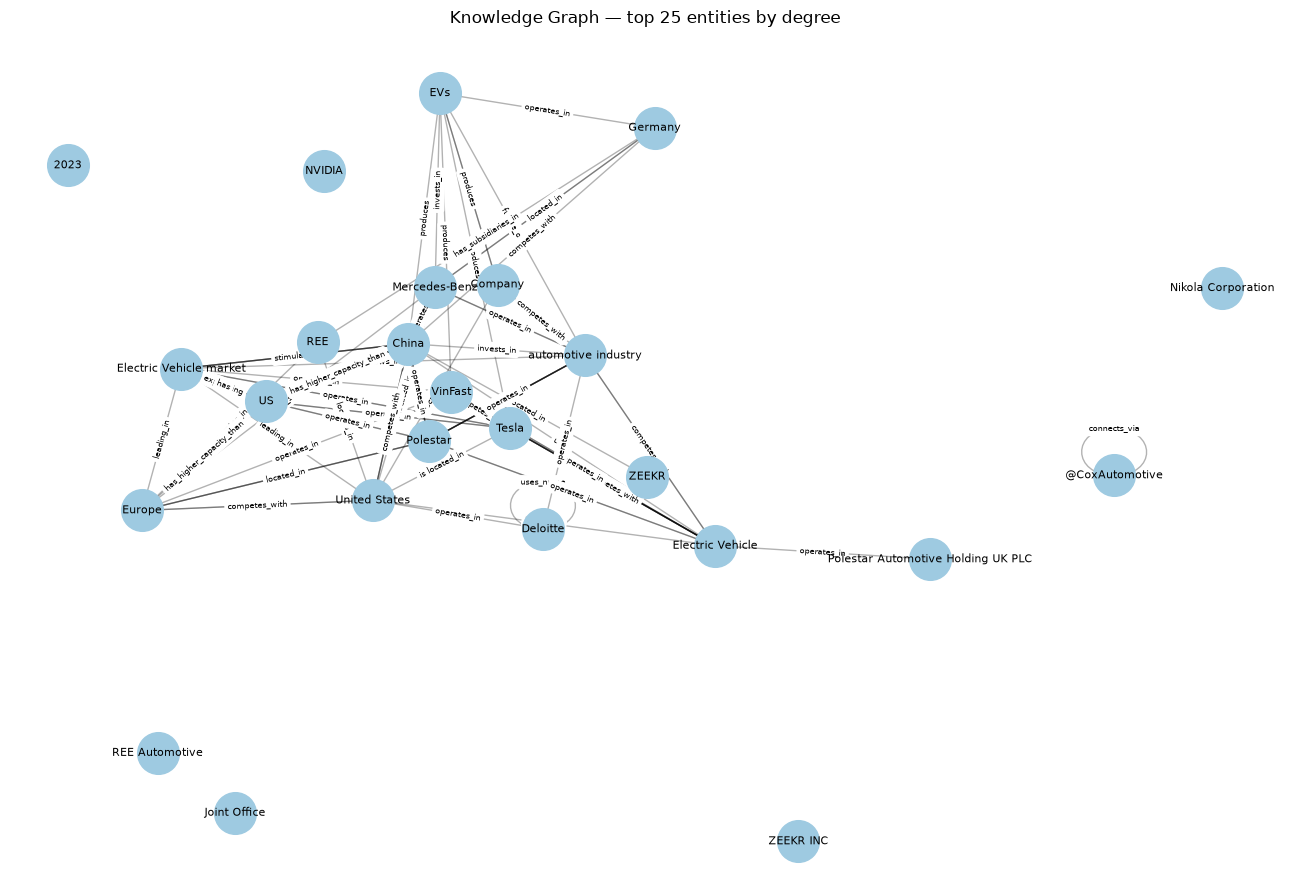

In [14]:
# Visualize the most-connected slice of the graph
top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:25]]
H = G.subgraph(top_nodes)

plt.figure(figsize=(13, 9))
pos = nx.spring_layout(H, k=0.6, seed=42)
nx.draw_networkx_nodes(H, pos, node_size=900, node_color="#9ecae1")
nx.draw_networkx_labels(H, pos, font_size=8)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=True)
nx.draw_networkx_edge_labels(
    H, pos, font_size=6,
    edge_labels={(u, v): d["relation"] for u, v, d in H.edges(data=True)})
plt.title("Knowledge Graph — top 25 entities by degree")
plt.axis("off"); plt.tight_layout()
plt.savefig("knowledge_graph.png", dpi=150, bbox_inches="tight")
print("saved knowledge_graph.png")
plt.show()

### (Optional) Mirror the graph into Neo4j

Runs only when `GRAPH_BACKEND == "neo4j"` and credentials are set — otherwise it is skipped,
so the notebook still runs fully offline.

In [15]:
if GRAPH_BACKEND == "neo4j":
    from neo4j import GraphDatabase
    driver = GraphDatabase.driver(NEO4J_URL, auth=(NEO4J_USER, NEO4J_PASSWORD))
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")
        for n, data in G.nodes(data=True):
            session.run("MERGE (e:Entity {name:$name}) SET e.type=$type",
                        name=n, type=data.get("type", ""))
        for u, v, data in G.edges(data=True):
            session.run(
                "MATCH (a:Entity {name:$u}), (b:Entity {name:$v}) "
                "MERGE (a)-[r:REL {type:$rel}]->(b) SET r.doc_id=$doc",
                u=u, v=v, rel=data.get("relation", ""), doc=data.get("doc_id", ""))
    driver.close()
    print("Pushed graph to Neo4j at", NEO4J_URL)
else:
    print("GRAPH_BACKEND != 'neo4j' -> skipping. Set GRAPH_BACKEND='neo4j' + creds in CONFIG to enable.")

GRAPH_BACKEND != 'neo4j' -> skipping. Set GRAPH_BACKEND='neo4j' + creds in CONFIG to enable.


**Multi-hop traversal in Cypher** (run in the Neo4j Browser once the graph is loaded):

```cypher
// 2-hop neighbourhood around an entity
MATCH path = (a:Entity {name: "Tesla"})-[*1..2]-(b:Entity)
RETURN path LIMIT 50;
```

## Part 5 — Vector Index (for the Flat RAG baseline)

A minimal cosine-similarity index over the chunk embeddings — this is what plain RAG retrieves from.

In [16]:
class VectorIndex:
    def __init__(self):
        self.ids, self.meta, self.matrix = [], {}, None

    def build(self, items, batch=128):
        self.ids = [it["chunk_id"] for it in items]
        self.meta = {it["chunk_id"]: it for it in items}
        vecs = []
        for i in tqdm(range(0, len(items), batch), desc="Embedding"):
            vecs.extend(embed([it["text"] for it in items[i:i + batch]]))
        m = np.vstack(vecs)
        self.matrix = m / (np.linalg.norm(m, axis=1, keepdims=True) + 1e-9)

    def search(self, query, k=4):
        q = embed(query)[0]
        q = q / (np.linalg.norm(q) + 1e-9)
        sims = self.matrix @ q
        order = np.argsort(-sims)[:k]
        return [(self.ids[i], float(sims[i]), self.meta[self.ids[i]]) for i in order]

vindex = VectorIndex()
vindex.build(chunks)
print("Vector index:", len(vindex.ids), "chunks, dim =", vindex.matrix.shape[1])

Embedding:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding:  25%|██▌       | 1/4 [00:02<00:06,  2.14s/it]

Embedding:  50%|█████     | 2/4 [00:03<00:03,  1.94s/it]

Embedding:  75%|███████▌  | 3/4 [00:05<00:01,  1.71s/it]

Embedding: 100%|██████████| 4/4 [00:06<00:00,  1.41s/it]

Embedding: 100%|██████████| 4/4 [00:06<00:00,  1.58s/it]

Vector index: 412 chunks, dim = 1536


## Part 6 — GraphRAG Querying (multi-hop)

The GraphRAG retrieval pipeline:

1. **Entity linking** — find graph nodes mentioned in the question.
2. **Multi-hop traversal** — expand a k-hop subgraph around those seeds.
3. **Verbalize** the subgraph edges into facts + pull the **provenance chunks**.
4. **Answer** from graph facts *and* supporting text.

In [ ]:
def link_entities(query, max_seeds=5):
    ql = query.lower()
    seeds = [n for n in G.nodes if n.lower() in ql]
    if not seeds:                      # fuzzy fallback on query tokens
        names = list(G.nodes)
        for token in re.findall(r"[A-Za-z][A-Za-z0-9&.\- ]{2,}", query):
            m = difflib.get_close_matches(token.strip().lower(),
                                          [x.lower() for x in names], n=1, cutoff=0.8)
            if m:
                seeds += [x for x in names if x.lower() == m[0] and x not in seeds]
    return sorted(set(seeds), key=lambda n: G.degree(n), reverse=True)[:max_seeds]

def k_hop_subgraph(seeds, hops=2, max_nodes=40):
    nodes, frontier = set(seeds), set(seeds)
    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt.update(G.successors(n)); nxt.update(G.predecessors(n))
        nodes.update(nxt); frontier = nxt
        if len(nodes) >= max_nodes:
            break
    return G.subgraph(list(nodes)[:max_nodes])

def verbalize(sg):
    lines = {f"({u}) -[{d.get('relation','related_to')}]-> ({v})"
             for u, v, d in sg.edges(data=True)}
    return "\n".join(sorted(lines))

def gather_chunks(sg, limit=6):
    cids, texts = [], []
    for n in sg.nodes:
        for cid in entity_chunks.get(n, []):
            if cid not in cids:
                cids.append(cid)
    by_id = {c["chunk_id"]: c for c in chunks}
    for cid in cids[:limit]:
        if cid in by_id:
            texts.append(f"[{cid}] " + by_id[cid]["text"][:600])
    return texts

def graphrag_answer(query, hops=2):
    seeds = link_entities(query)
    sg = k_hop_subgraph(seeds, hops=hops)
    facts = verbalize(sg)
    evidence = "\n\n".join(gather_chunks(sg))
    prompt = (
        "Answer the question using the KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT below. "
        "Reason across multiple connected facts (multi-hop) when needed. "
        "If the context is insufficient, say so.\n\n"
        "QUESTION: " + query + "\n\n"
        "KNOWLEDGE-GRAPH FACTS:\n" + (facts or "(none found)") + "\n\n"
        "SUPPORTING TEXT:\n" + (evidence or "(none)") + "\n\n"
        "ANSWER:"
    )
    return {"answer": llm_complete(prompt, max_tokens=500), "seeds": seeds,
            "n_facts": len(facts.splitlines()) if facts else 0}

In [18]:
q = "How does the electric vehicle sector connect to charging infrastructure and government policy?"
res = graphrag_answer(q, hops=2)
print("Seed entities:", res["seeds"])
print("Graph facts used:", res["n_facts"])
print("\nGraphRAG answer:\n", res["answer"])

Seed entities: ['Electric Vehicle', 'Charging infrastructure', 't', 'SEC', 'infrastructure']
Graph facts used: 42

GraphRAG answer:
 The electric vehicle (EV) sector is closely connected to charging infrastructure and government policy in several ways:

1. **Government Support and Policy**: The promotion of electric vehicles is significantly influenced by government policies, including subsidies and post-coronavirus stimulus plans. These policies are designed to encourage the adoption of EVs, which helps to reduce emissions and improve public health. Government subsidies make EVs more financially accessible, thereby increasing their market share and adoption rates.

2. **Charging Infrastructure Development**: As the adoption of electric vehicles grows, the need for robust charging infrastructure becomes critical. Government policies often include investments in charging networks to support the increasing number of EVs on the road. This infrastructure is essential for alleviating range 

## Part 7 — Flat RAG Baseline

Plain retrieval: embed the query, grab the top-k most similar chunks, answer from those passages only.

In [19]:
def flat_rag_answer(query, k=4):
    hits = vindex.search(query, k=k)
    context = "\n\n".join(f"[{cid}] " + meta["text"][:700] for cid, _, meta in hits)
    prompt = (
        "Answer the question using ONLY the context passages below. "
        "If the answer is not in the context, say you don't have enough information.\n\n"
        "QUESTION: " + query + "\n\n"
        "CONTEXT:\n" + context + "\n\n"
        "ANSWER:"
    )
    return {"answer": llm_complete(prompt, max_tokens=500),
            "sources": [cid for cid, _, _ in hits]}

fr = flat_rag_answer(q)
print("Sources:", fr["sources"])
print("\nFlat RAG answer:\n", fr["answer"])

Sources: ['doc_27.txt::ch3', 'doc_29.txt::ch3', 'doc_18.txt::ch14', 'doc_27.txt::ch2']

Flat RAG answer:
 The electric vehicle sector connects to charging infrastructure and government policy through the need for public sector support for charging solutions, such as curbside Level 2 charging, to provide mobility choices for those without home charging access. Government policies, including the National Electric Vehicle Infrastructure (NEVI) Formula Program, invite private sector participation to develop charging infrastructure. Additionally, continued government support is necessary to ensure equitable access to charging and to sustain a charging network until there are enough EVs on the road.


## Part 8 — Flat RAG vs GraphRAG Comparison

Run the same question set through both pipelines. Look for questions that require *connecting*
entities across documents — that is where GraphRAG's multi-hop traversal tends to win, while
Flat RAG is limited to whatever a single similar passage happens to contain.

In [20]:
# 20 benchmark questions over the US-EV-sector corpus.
# Several are intentionally multi-hop ("connect X to Y across documents") — where GraphRAG tends to win.
questions = [
    "How does the electric vehicle sector connect to charging infrastructure and government policy?",
    "Which companies are mentioned in relation to EV market growth, and how are they connected?",
    "What financial trends or sentiments are associated with the EV sector?",
    "How do government incentives relate to EV adoption across regions?",
    "What is the relationship between Tesla and the broader US EV market?",
    "Which states or regions are linked to the strongest EV adoption, and why?",
    "How is investor sentiment connected to EV company stock performance?",
    "What policies are associated with zero-emission vehicles?",
    "How does charging infrastructure availability relate to EV uptake?",
    "Which EV companies are compared against Tesla, and on what metrics?",
    "What connects consumer incentives to electric vehicle market share?",
    "How do US EV market sentiments compare to the global market?",
    "What factors are linked to electric vehicle sales growth in the US?",
    "How are EV startups financially positioned relative to established automakers?",
    "What is the connection between ZEV regulations and model availability?",
    "Which metrics are used to evaluate EV company financial performance?",
    "How does workplace and public charging relate to regional EV adoption?",
    "What risks or negative sentiments are associated with EV stocks?",
    "How are battery technology and EV range connected in the corpus?",
    "What links state-level policy to national EV sales totals?",
]

rows = []
for ques in tqdm(questions, desc="Comparing"):
    g = graphrag_answer(ques, hops=2)
    f = flat_rag_answer(ques, k=4)
    rows.append({"question": ques,
                 "graph_seeds": ", ".join(g["seeds"]) or "(none)",
                 "n_graph_facts": g["n_facts"],
                 "graphrag_answer": g["answer"],
                 "flatrag_answer": f["answer"]})

pd.set_option("display.max_colwidth", 350)
comparison = pd.DataFrame(rows)
comparison.to_csv("comparison_flatrag_vs_graphrag.csv", index=False)
print("saved comparison_flatrag_vs_graphrag.csv  (", len(comparison), "questions )")
comparison

Comparing:   0%|          | 0/20 [00:00<?, ?it/s]

Comparing:   5%|▌         | 1/20 [00:09<02:54,  9.20s/it]

Comparing:  10%|█         | 2/20 [00:16<02:21,  7.89s/it]

Comparing:  15%|█▌        | 3/20 [00:24<02:14,  7.89s/it]

Comparing:  20%|██        | 4/20 [00:32<02:09,  8.07s/it]

...

Comparing:  95%|█████████▌| 19/20 [02:09<00:06,  6.70s/it]

Comparing: 100%|██████████| 20/20 [02:16<00:00,  6.83s/it]

Comparing: 100%|██████████| 20/20 [02:16<00:00,  6.83s/it]

saved comparison_flatrag_vs_graphrag.csv  ( 20 questions )


,question,graph_seeds,n_graph_facts,graphrag_answer,flatrag_answer
0,How does the electric vehicle sector connect to charging infrastructure and government policy?,"Electric Vehicle, Charging infrastructure, t, SEC, infrastructure",42,"The electric vehicle (EV) sector is closely connected to charging infrastructure and government policy in several ways:\n\n1. **Government Support and Policy**: The promotion of electric vehicles is significantly influenced by government policies, including subsidies and post-coronavirus stimulus plans. These policies aim to encourage the adopt...","The electric vehicle sector connects to charging infrastructure and government policy through the need for public sector support for charging options, such as curbside Level 2 charging, to provide mobility choices for those without home charging access. Government policies, including the National Electric Vehicle Infrastructure (NEVI) Formula P..."
1,"Which companies are mentioned in relation to EV market growth, and how are they connected?","market, companies, EV, t, growth",43,The companies mentioned in relation to EV market growth include those that are involved in the electric vehicle sector and are seeking to differentiate themselves by acting as a force for positive change. These companies are connected through their efforts to support the transition to electric vehicles (EVs) and their engagement with government...,"The companies mentioned in relation to EV market growth are Tesla, BYD, VinFast, Polestar, Canoo, Fisker, Lucid, and Nikola. They are connected through their involvement in the electric vehicle market, with Tesla and BYD being established players whose stock performance has declined, while the emerging players like VinFast, Polestar, Canoo, Fis..."
2,What financial trends or sentiments are associated with the EV sector?,"EV, t, EV sector, SEC, sentiment",0,"The financial trends and sentiments associated with the electric vehicle (EV) sector indicate a growing demand and optimism for future growth. Key points include:\n\n1. **Consumer Behavior Changes**: Research suggests that consumer intentions regarding vehicle ownership are shifting, with many planning to keep their current vehicles longer. Thi...","The financial trends and sentiments associated with the EV sector include a significant decline in investor confidence, as indicated by a 20-year low in investor sentiment. The EV industry is experiencing a downward trend due to increased competition, geopolitical tensions, supply chain disruptions, high energy prices, and rising inflation and ..."
3,How do government incentives relate to EV adoption across regions?,"incentives, EV adoption, EV, t, government incentives",43,"Government incentives play a crucial role in the adoption of electric vehicles (EVs) across different regions. These incentives can take various forms, such as subsidies, tax credits, and other financial benefits aimed at reducing the overall cost of EVs for consumers.\n\n1. **Regional Incentives**: Specific regions like California, Colorado, N...","Government incentives play a significant role in promoting EV adoption across regions by providing financial support such as cash subsidies, tax reductions, and scrappage schemes. For instance, Germany has lowered VAT on low-emission vehicles and increased subsidies for EVs, while France offers substantial incentives for consumers purchasing el..."
4,What is the relationship between Tesla and the broader US EV market?,"Tesla, US, market, EV, t",16,"Tesla plays a significant role in the broader US electric vehicle (EV) market, which is currently experiencing a complex landscape influenced by various factors. While Tesla is a leading manufacturer of EVs in the US, the market is also characterized by increasing competition from both domestic and international players, such as VinFast and est...","Tesla is a significant player in the broader US EV market, holding a substantial share of 51.3% in Q1 2024, although this is a

In [21]:
# Read the full answers side by side
for r in rows:
    print("=" * 90)
    print("Q:", r["question"])
    print("seeds:", r["graph_seeds"])
    print("\n-- GraphRAG --\n", r["graphrag_answer"])
    print("\n-- Flat RAG --\n", r["flatrag_answer"], "\n")

Q: How does the electric vehicle sector connect to charging infrastructure and government policy?
seeds: Electric Vehicle, Charging infrastructure, t, SEC, infrastructure

-- GraphRAG --
 The electric vehicle (EV) sector is closely connected to charging infrastructure and government policy in several ways:

1. **Government Support and Policy**: The promotion of electric vehicles is significantly influenced by government policies, including subsidies and post-coronavirus stimulus plans. These policies aim to encourage the adoption of EVs by making them more financially accessible to consumers. Government subsidies can help offset the higher costs associated with purchasing and registering electric vehicles, which are generally more expensive than conventional vehicles.

2. **Charging Infrastructure Development**: As the adoption of electric vehicles increases, the need for robust charging infrastructure becomes critical. Government policies often include investments in charging networks

## Part 9 — Conclusion & Takeaways

**What we built:** a complete GraphRAG pipeline — extraction (LangExtract or prompt) → dedup →
knowledge graph → multi-hop retrieval → grounded answer — plus a Flat RAG baseline for comparison,
all behind provider/backend switches (Ollama/OpenAI, NetworkX/Neo4j, LangExtract/prompt).

**When GraphRAG wins:** questions that require *connecting* facts spread across documents
("how is A related to C through B"). The graph encodes those relationships explicitly, so traversal
surfaces them even when no single passage states the connection.

**When Flat RAG is enough:** direct lookups where the answer sits inside one passage — it is simpler
and cheaper (no extraction step).

**Knobs to explore:**
- Raise `MAX_DOCS` toward the full corpus and re-run.
- Switch `EXTRACTION_BACKEND` between `langextract` (few-shot, grounded) and `prompt` (baseline).
- Increase `hops` (2 → 3) for deeper multi-hop reasoning.
- Tighten the extraction prompt / dedup `cutoff` for a cleaner graph.
- Switch `LLM_PROVIDER` to `openai` for higher-quality extraction and answers.

**Interview-style questions to check understanding:**
1. Why does poor entity deduplication degrade GraphRAG more than Flat RAG?
2. How does multi-hop traversal answer questions that vector similarity alone cannot?
3. What are the cost/latency trade-offs of the extraction step versus plain embedding?
4. How would you evaluate GraphRAG vs Flat RAG quantitatively (e.g., an LLM judge or a labelled QA set)?

In [22]:
# ---- Deliverable #4: cost analysis (token usage + time) ----
# gpt-4o-mini & text-embedding-3-small list prices (USD per 1M tokens), Jan 2025.
PRICE = {"in": 0.15, "out": 0.60, "embed": 0.02}
llm_cost   = USAGE["prompt_tokens"]/1e6*PRICE["in"] + USAGE["completion_tokens"]/1e6*PRICE["out"]
embed_cost = USAGE["embed_tokens"]/1e6*PRICE["embed"]

cost = {
    **USAGE,
    "extract_seconds": round(globals().get("EXTRACT_SECONDS", 0.0), 1),
    "n_chunks": len(chunks),
    "n_triples": len(all_triples),
    "n_nodes": G.number_of_nodes(),
    "n_edges": G.number_of_edges(),
    "est_llm_cost_usd": round(llm_cost, 4),
    "est_embed_cost_usd": round(embed_cost, 4),
    "est_total_cost_usd": round(llm_cost + embed_cost, 4),
}
import json as _json
with open("cost_report.json", "w") as fh:
    _json.dump(cost, fh, indent=2)

print("=== Cost / build analysis ===")
for k, v in cost.items():
    print(f"  {k:22}: {v}")
print("\nsaved cost_report.json")
print(f"\nIndexing built a {cost['n_nodes']}-node / {cost['n_edges']}-edge graph from "
      f"{cost['n_chunks']} chunks for ~${cost['est_total_cost_usd']} "
      f"({USAGE['llm_calls']} LLM calls, extraction wall-time {cost['extract_seconds']}s).")

=== Cost / build analysis ===
  llm_calls             : 456
  prompt_tokens         : 212754
  completion_tokens     : 168233
  embed_calls           : 26
  embed_tokens          : 102903
  llm_seconds           : 2850.331817150116
  embed_seconds         : 16.951279640197754
  extract_seconds       : 229.4
  n_chunks              : 412
  n_triples             : 5646
  n_nodes               : 4702
  n_edges               : 5646
  est_llm_cost_usd      : 0.1329
  est_embed_cost_usd    : 0.0021
  est_total_cost_usd    : 0.1349

saved cost_report.json

Indexing built a 4702-node / 5646-edge graph from 412 chunks for ~$0.1349 (456 LLM calls, extraction wall-time 229.4s).
